<a href="https://colab.research.google.com/github/kartikdhoke9923/Ai-and-dl/blob/main/stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#  STOCK PREDICTION PIPELINE
# Install & Imports

# !pip install -q tensorflow scikit-learn pandas numpy matplotlib

In [112]:
"""
Stock Prediction Pipeline
Predicts next N days: Open, High, Low, Close + Moving Averages
Usage:
    from stock_pipeline import run_pipeline
    run_pipeline("your_file.csv", forecast_days=30)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

# Upload CSV file


In [113]:
from google.colab import files

uploaded = files.upload()                     # click "Choose Files" → pick your CSV
FILE_PATH = list(uploaded.keys())[0]          # auto-detects uploaded filename
print(f"Using file: {FILE_PATH}")

Saving Volkswagen_Stock_15Years_Complete.csv to Volkswagen_Stock_15Years_Complete (1).csv
Using file: Volkswagen_Stock_15Years_Complete (1).csv



# Pipeline Config  (change these as needed)


In [114]:
WINDOW        = 20      # how many past days the model looks at
FORECAST_DAYS = 30      # how many future days to predict
EPOCHS        = 50      # max training epochs (EarlyStopping will cut this short)
BATCH_SIZE    = 32

OUTPUT_DIR    = "/content/"    # all output files saved here in Colab


# Step 1: Load & Clean


In [115]:
def load_and_clean(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True)
    df = df.sort_values('Date').reset_index(drop=True)

    ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in ohlcv:
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].str.replace(',', '').str.replace('$', '')
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=ohlcv)
    df = df.drop_duplicates(subset='Date')
    df = df.reset_index(drop=True)
    print(f"[LOAD] {len(df)} rows | {df['Date'].min().date()} → {df['Date'].max().date()}")
    return df

df_raw = load_and_clean(FILE_PATH)
df_raw.tail(3)


[LOAD] 3915 rows | 2011-04-11 → 2026-04-10


,Date,Open,High,Low,Close,Volume
3912,2026-04-08,131.10,131.33,130.48,131.21,66798142
3913,2026-04-09,128.60,128.72,128.45,128.50,129563206
3914,2026-04-10,127.07,128.55,126.32,127.66,42322698


# Step 2: Feature Engineering


In [116]:
def create_features(df):
    df = df.copy()

    df['Return_1']     = df['Close'].pct_change(1)
    df['Return_5']     = df['Close'].pct_change(5)

    df['MA_5']         = df['Close'].rolling(5).mean()
    df['MA_10']        = df['Close'].rolling(10).mean()
    df['MA_20']        = df['Close'].rolling(20).mean()
    df['EMA_9']        = df['Close'].ewm(span=9,  adjust=False).mean()
    df['EMA_21']       = df['Close'].ewm(span=21, adjust=False).mean()

    df['Volatility']   = df['Close'].rolling(5).std()
    df['HL_Spread']    = df['High'] - df['Low']
    df['OC_Spread']    = df['Close'] - df['Open']

    df['Momentum_5']   = df['Close'] - df['Close'].shift(5)
    df['Momentum_10']  = df['Close'] - df['Close'].shift(10)

    df['Volume_MA5']   = df['Volume'].rolling(5).mean()
    df['Volume_Ratio'] = df['Volume'] / (df['Volume_MA5'] + 1e-9)

    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

    df = df.dropna().reset_index(drop=True)
    print(f"[FEATURES] Shape: {df.shape}")
    return df

df_feat = create_features(df_raw)
df_feat.tail(3)

[FEATURES] Shape: (3896, 21)


,Date,Open,High,Low,Close,Volume,Return_1,Return_5,MA_5,MA_10,...,EMA_9,EMA_21,Volatility,HL_Spread,OC_Spread,Momentum_5,Momentum_10,Volume_MA5,Volume_Ratio,RSI
3893,2026-04-08,131.10,131.33,130.48,131.21,66798142,0.010863,0.036660,129.178,128.825,...,129.026393,127.965399,1.641971,0.85,0.11,4.64,0.79,77933413.0,0.857118,55.206107
3894,2026-04-09,128.60,128.72,128.45,128.50,129563206,-0.020654,-0.010244,128.912,129.016,...,128.921114,128.013999,1.617489,0.27,-0.10,-1.33,1.91,79997950.0,1.619582,50.848416
3895,2026-04-10,127.07,128.55,126.32,127.66,42322698,-0.006537,-0.002344,128.852,128.712,...,128.668891,127.981817,1.666454,2.23,0.59,-0.30,-3.04,84862130.0,0.498723,51.444921


# Step 3: Scale Data


In [117]:
FEATURE_COLS = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Return_1', 'Return_5',
    'MA_5', 'MA_10', 'MA_20', 'EMA_9', 'EMA_21',
    'Volatility', 'HL_Spread', 'OC_Spread',
    'Momentum_5', 'Momentum_10',
    'Volume_MA5', 'Volume_Ratio', 'RSI'
]
TARGET_COLS = ['Open', 'High', 'Low', 'Close']

def scale_data(df):
    df = df.copy()
    feature_scaler = MinMaxScaler()
    target_scaler  = MinMaxScaler()
    df[FEATURE_COLS] = feature_scaler.fit_transform(df[FEATURE_COLS])
    df[TARGET_COLS]  = target_scaler.fit_transform(df[TARGET_COLS])
    return df, feature_scaler, target_scaler

df_scaled, feature_scaler, target_scaler = scale_data(df_feat)
print("[SCALE] Done.")

[SCALE] Done.



# Step 4: Create Sequences


In [118]:
def create_sequences(df, window=20):
    feature_data = df[FEATURE_COLS].values
    target_data  = df[TARGET_COLS].values
    X, y = [], []
    for i in range(len(feature_data) - window):
        X.append(feature_data[i : i + window])
        y.append(target_data[i + window])
    X, y = np.array(X), np.array(y)
    print(f"[SEQUENCES] X: {X.shape} | y: {y.shape}")
    return X, y

X, y = create_sequences(df_scaled, window=WINDOW)

[SEQUENCES] X: (3876, 20, 20) | y: (3876, 4)



# Step 5: Build & Train Model


In [119]:
def build_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(4)          # Open, High, Low, Close
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_model(X, y, epochs=50, batch_size=32):
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = build_model((X.shape[1], X.shape[2]))
    model.summary()

    early_stop = EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    return model, X_test, y_test, history

model, X_test, y_test, history = train_model(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 20, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,908 (499.64 KB)

 Trainable params: 127,908 (499.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0177 - mae: 0.0880 - val_loss: 6.9884e-04 - val_mae: 0.0208
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0040 - mae: 0.0470 - val_loss: 0.0012 - val_mae: 0.0300
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0033 - mae: 0.0422 - val_loss: 0.0021 - val_mae: 0.0419
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0025 - mae: 0.0365 - val_loss: 7.6175e-04 - val_mae: 0.0225
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0024 - mae: 0.0354 - val_loss: 4.0734e-04 - val_mae: 0.0161
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0020 - mae: 0.0327 - val_loss: 0.0010 - val_mae: 0.0267
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 0.0018 - mae: 0.0311 - val_loss: 3.8274e-04 - val_mae: 0.0157
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0017 - mae: 0.0297 - val_loss: 9.5879e-04 - val_mae: 0.0256
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 43m

# Step 6: Evaluate on Test Set

In [120]:
def evaluate_model(model, X_test, y_test, target_scaler):
    preds_scaled = model.predict(X_test, verbose=0)
    preds   = target_scaler.inverse_transform(preds_scaled)
    actuals = target_scaler.inverse_transform(y_test)

    print("\n── Test Set Evaluation (original price scale) ──")
    for i, col in enumerate(TARGET_COLS):
        mae  = mean_absolute_error(actuals[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(actuals[:, i], preds[:, i]))
        print(f"  {col:5s} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return preds, actuals

test_preds, test_actuals = evaluate_model(model, X_test, y_test, target_scaler)


── Test Set Evaluation (original price scale) ──
  Open  | MAE: 0.0151 | RMSE: 0.0189
  High  | MAE: 0.0154 | RMSE: 0.0192
  Low   | MAE: 0.0154 | RMSE: 0.0191
  Close | MAE: 0.0145 | RMSE: 0.0182


# Step 7: Predict Future (Recursive)

In [121]:
def predict_future(model, last_sequence, target_scaler, days=30):
    current_seq = last_sequence.copy()
    predictions_scaled = []

    c_idx = FEATURE_COLS.index('Close')
    o_idx = FEATURE_COLS.index('Open')
    h_idx = FEATURE_COLS.index('High')
    l_idx = FEATURE_COLS.index('Low')

    for _ in range(days):
        pred_scaled = model.predict(
            current_seq.reshape(1, *current_seq.shape), verbose=0
        )[0]
        predictions_scaled.append(pred_scaled)

        new_row          = current_seq[-1].copy()
        new_row[o_idx]   = pred_scaled[0]
        new_row[h_idx]   = pred_scaled[1]
        new_row[l_idx]   = pred_scaled[2]
        new_row[c_idx]   = pred_scaled[3]

        # Approximate rolling MAs from visible window
        window_closes = np.append(current_seq[1:, c_idx], pred_scaled[3])
        new_row[FEATURE_COLS.index('MA_5')]  = window_closes[-5:].mean()
        new_row[FEATURE_COLS.index('MA_10')] = window_closes[-10:].mean() if len(window_closes) >= 10 else window_closes.mean()
        new_row[FEATURE_COLS.index('MA_20')] = window_closes.mean()

        current_seq = np.vstack([current_seq[1:], new_row])

    predictions = target_scaler.inverse_transform(np.array(predictions_scaled))
    return predictions

future_preds = predict_future(model, X[-1], target_scaler, days=FORECAST_DAYS)
print(f"[FORECAST] Predicted {FORECAST_DAYS} days of OHLC.")


[FORECAST] Predicted 30 days of OHLC.


# Step 8: Visualise Results

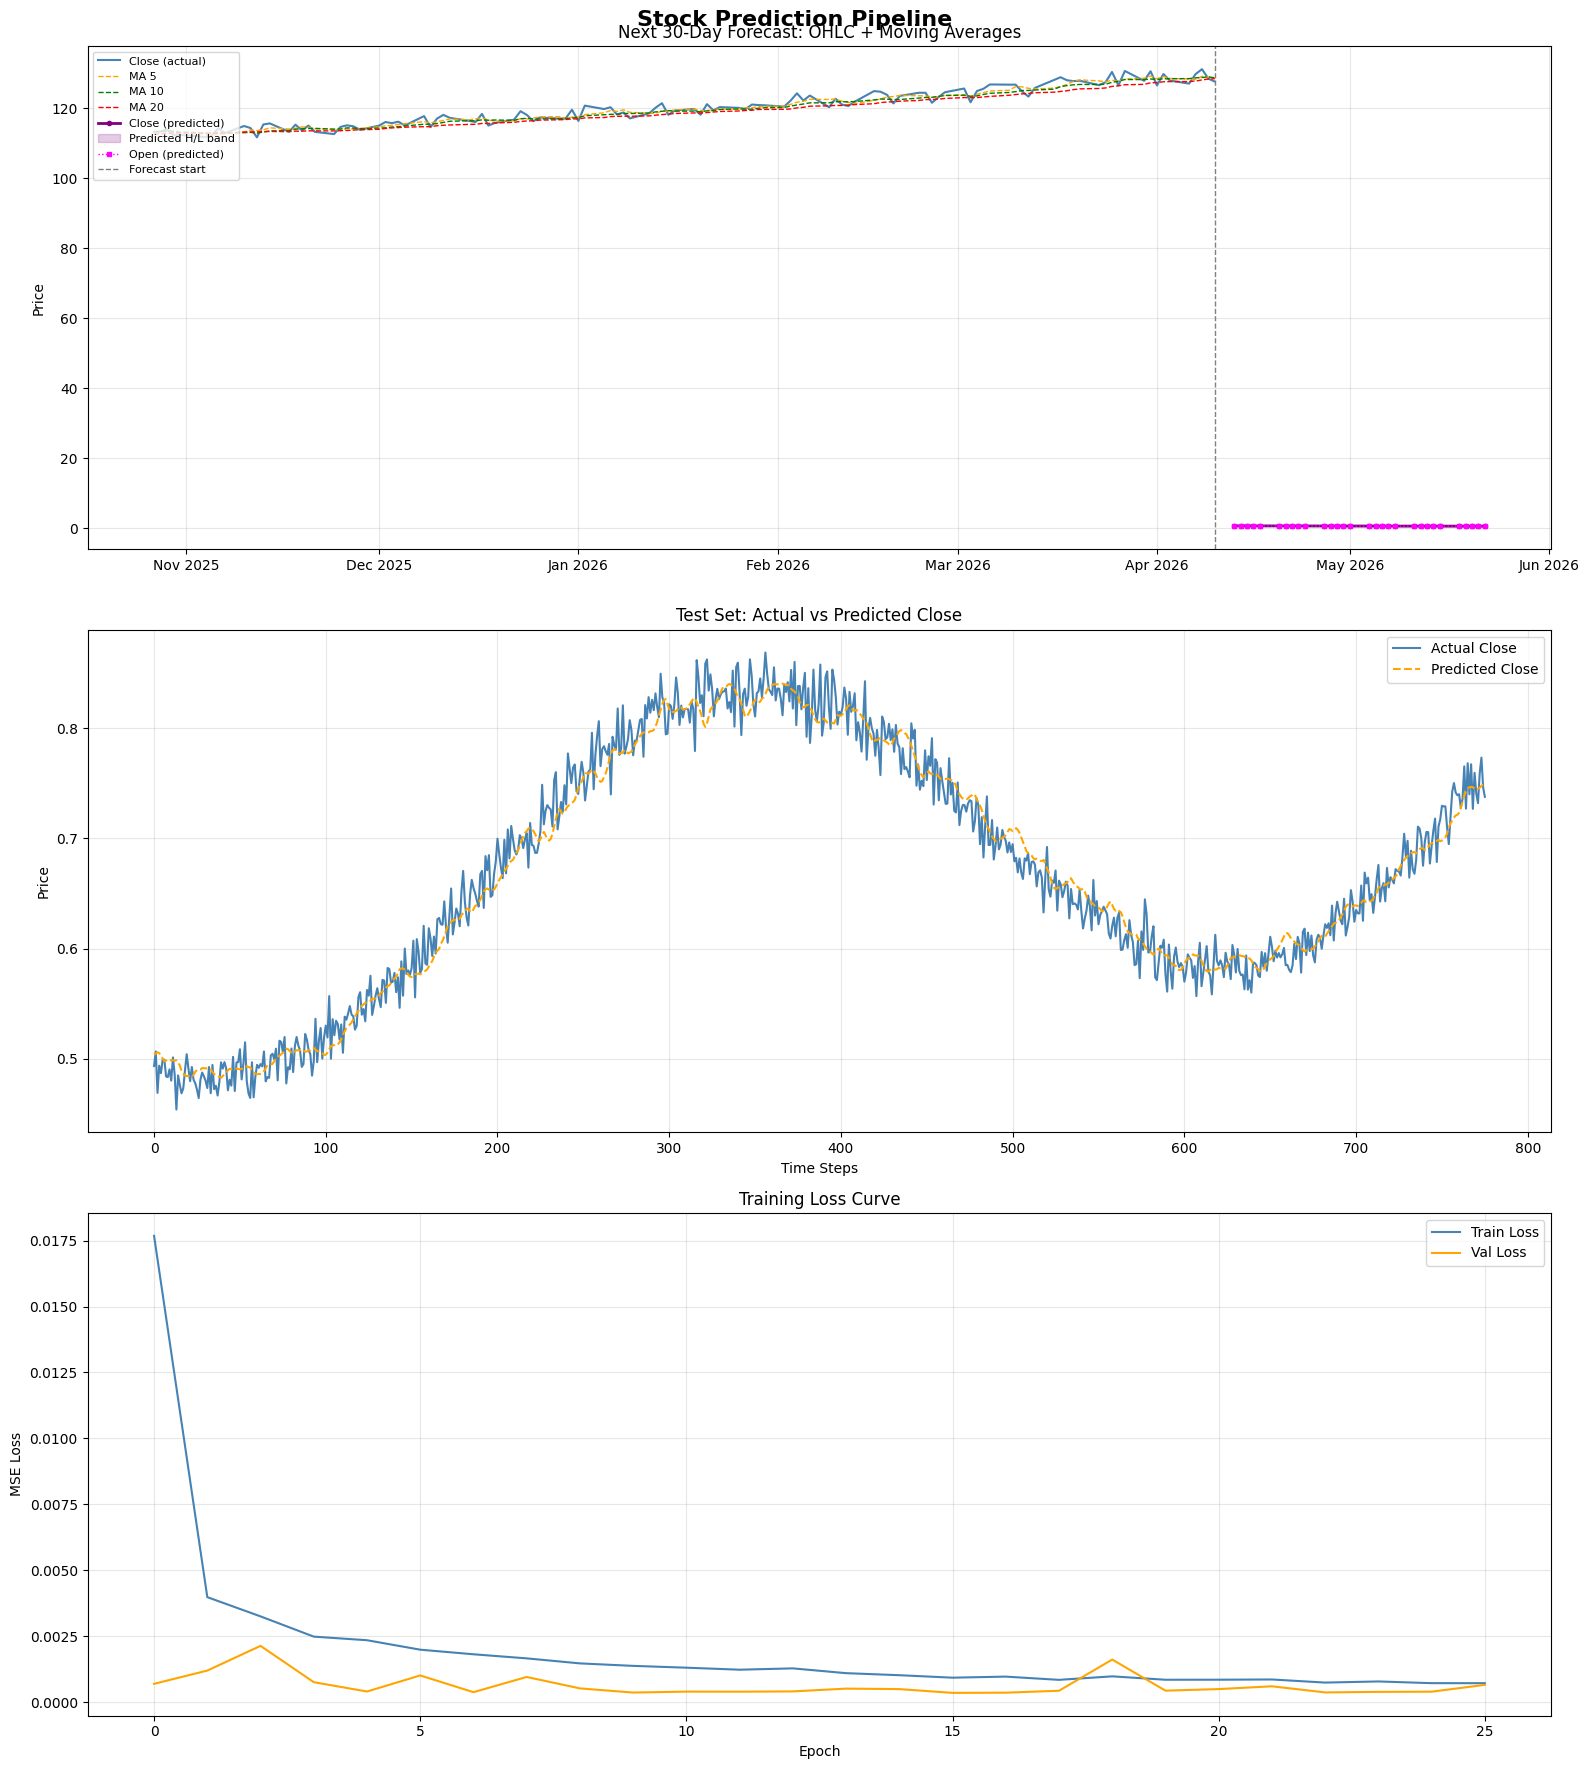

[PLOT] Saved → /content/stock_forecast.png


In [122]:
def plot_results(df_feat, future_preds, history, test_actuals, test_preds,
                 lookback_days=120, output_dir="/content/"):

    fig, axes = plt.subplots(3, 1, figsize=(16, 18))
    fig.suptitle("Stock Prediction Pipeline", fontsize=16, fontweight='bold')

    # ── Panel 1: Forecast ────────────────────────────────────
    ax = axes[0]
    recent = df_feat.tail(lookback_days)

    ax.plot(recent['Date'], recent['Close'],  label='Close (actual)',  color='steelblue', lw=1.5)
    ax.plot(recent['Date'], recent['MA_5'],   label='MA 5',  color='orange', lw=1, ls='--')
    ax.plot(recent['Date'], recent['MA_10'],  label='MA 10', color='green',  lw=1, ls='--')
    ax.plot(recent['Date'], recent['MA_20'],  label='MA 20', color='red',    lw=1, ls='--')

    future_dates = pd.date_range(
        start=df_feat['Date'].iloc[-1] + pd.Timedelta(days=1),
        periods=FORECAST_DAYS, freq='B'
    )

    ax.plot(future_dates, future_preds[:, 3],
            label='Close (predicted)', color='purple', lw=2, marker='o', ms=3)
    ax.fill_between(future_dates, future_preds[:, 2], future_preds[:, 1],
                    alpha=0.2, color='purple', label='Predicted H/L band')
    ax.plot(future_dates, future_preds[:, 0],
            label='Open (predicted)', color='magenta', lw=1, ls=':', marker='s', ms=3)

    ax.axvline(x=df_feat['Date'].iloc[-1], color='gray', ls='--', lw=1, label='Forecast start')
    ax.set_title(f"Next {FORECAST_DAYS}-Day Forecast: OHLC + Moving Averages")
    ax.set_ylabel("Price")
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.grid(True, alpha=0.3)

    # ── Panel 2: Test Set Accuracy ───────────────────────────
    ax2 = axes[1]
    ax2.plot(test_actuals[:, 3], label='Actual Close',    color='steelblue', lw=1.5)
    ax2.plot(test_preds[:, 3],   label='Predicted Close', color='orange',    lw=1.5, ls='--')
    ax2.set_title("Test Set: Actual vs Predicted Close")
    ax2.set_xlabel("Time Steps")
    ax2.set_ylabel("Price")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ── Panel 3: Training Loss ───────────────────────────────
    ax3 = axes[2]
    ax3.plot(history.history['loss'],     label='Train Loss', color='steelblue')
    ax3.plot(history.history['val_loss'], label='Val Loss',   color='orange')
    ax3.set_title("Training Loss Curve")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("MSE Loss")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = output_dir + "stock_forecast.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[PLOT] Saved → {save_path}")

plot_results(df_feat, future_preds, history, test_actuals, test_preds,
             lookback_days=120, output_dir=OUTPUT_DIR)


# Step 9: Export Forecast Table & Download

In [123]:
future_dates = pd.date_range(
    start=df_feat['Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=FORECAST_DAYS, freq='B'
)

forecast_df = pd.DataFrame({
    'Date'  : future_dates,
    'Open'  : future_preds[:, 0].round(4),
    'High'  : future_preds[:, 1].round(4),
    'Low'   : future_preds[:, 2].round(4),
    'Close' : future_preds[:, 3].round(4),
})

csv_path = OUTPUT_DIR + "forecast_table.csv"
forecast_df.to_csv(csv_path, index=False)
print(f"[EXPORT] Saved → {csv_path}")
print(forecast_df.to_string(index=False))

# Auto-download both files to your local machine
files.download(csv_path)
files.download(OUTPUT_DIR + "stock_forecast.png")

[EXPORT] Saved → /content/forecast_table.csv
      Date   Open   High    Low  Close
2026-04-13 0.7520 0.7400 0.7490 0.7497
2026-04-14 0.7505 0.7392 0.7487 0.7494
2026-04-15 0.7476 0.7371 0.7472 0.7478
2026-04-16 0.7438 0.7339 0.7446 0.7452
2026-04-17 0.7393 0.7299 0.7413 0.7418
2026-04-20 0.7347 0.7256 0.7376 0.7381
2026-04-21 0.7302 0.7213 0.7337 0.7343
2026-04-22 0.7258 0.7169 0.7299 0.7304
2026-04-23 0.7214 0.7125 0.7259 0.7264
2026-04-24 0.7172 0.7083 0.7220 0.7225
2026-04-27 0.7131 0.7041 0.7180 0.7186
2026-04-28 0.7093 0.7002 0.7143 0.7148
2026-04-29 0.7057 0.6965 0.7107 0.7112
2026-04-30 0.7021 0.6929 0.7073 0.7077
2026-05-01 0.6986 0.6893 0.7038 0.7043
2026-05-04 0.6952 0.6859 0.7005 0.7009
2026-05-05 0.6921 0.6826 0.6971 0.6977
2026-05-06 0.6890 0.6796 0.6941 0.6947
2026-05-07 0.6861 0.6765 0.6911 0.6917
2026-05-08 0.6832 0.6736 0.6882 0.6888
2026-05-11 0.6805 0.6709 0.6855 0.6861
2026-05-12 0.6779 0.6683 0.6829 0.6835
2026-05-13 0.6753 0.6658 0.6804 0.6810
2026-05-14 0.6728 0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>